In [1]:
## Peizhi Yan 2025 Copyright.

"""
In this demo we train a simple transformer network model for machine translation task
"""

import torch
import torch.nn.functional as F
import numpy as np
import random
import matplotlib.pyplot as plt
from time import time
from tqdm import tqdm

from transformer_utils import PositionalEncoding, generate_mask, SimpleTokenizer
from transformer_lite import GPT

# device = 'cpu'
# select the device to run the model (priority: cuda > mps > cpu)
device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
print('Computing Device: ', device)

# define some hyperparameters
BATCH_SIZE = 16
MAX_LENGTH = 60     # the maximum amount of "tokens" in a sequence
DIMENSION = 128     # the dimension of each "token" embedding
ATTN_HEADS = 8      # the number of attention heads
NUM_BLOCKS = 6      # the number of transformer encoder/decoder blocks


Computing Device:  mps


### Positional Encoding

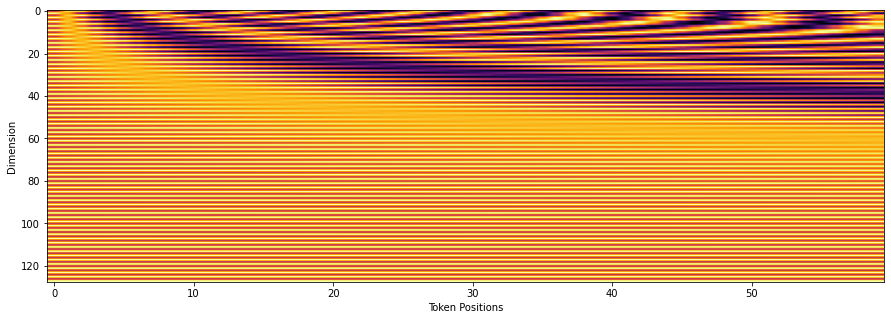

In [3]:
PE = PositionalEncoding(max_length=MAX_LENGTH, dim=DIMENSION, device=device)
x = torch.zeros([1, MAX_LENGTH, DIMENSION]).to(device) # batch = 1, sequence length = 100
x_pe = PE(x)
plt.figure(figsize=(15,5))
plt.imshow(x_pe[0].T.cpu(), cmap='inferno', aspect='auto')
plt.xlabel('Token Positions'); plt.ylabel('Dimension')
plt.show()


### Data, Tokenization, Embedding

Tokens:  ['<BEGIN>', 'W', 'i', 't', 'h', ' ', 'b', 'a', 't', 's', ' ', 'a', 'n', 'd', ' ', 'c', 'l', 'u', 'b', 's', '?', ' ', 'T', 'h', 'e', ' ', 'm', 'a', 't', 't', 'e', 'r', '?', ' ', 's', 'p', 'e', 'a', 'k', ',', ' ', 'I', ' ', 'p', 'r', 'a', 'y', ' ', 'y', 'o', 'u', '.', '<EOS>', '<EMPTY>', '<EMPTY>', '<EMPTY>', '<EMPTY>', '<EMPTY>', '<EMPTY>', '<EMPTY>']
Text reconstructed from tokens:  With bats and clubs? The matter? speak, I pray you.
torch.Size([1, 60, 128])


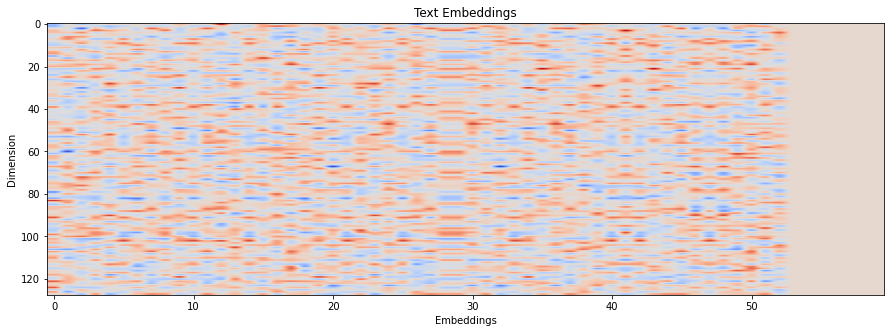

In [6]:
# load the data
texts = []
data_path = './data/tinyshakespeare.txt'
with open(data_path, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if len(line) > 0:
            texts.append(line)

corpus = texts

# create a simple tokenizer from the corpus
tokenizer = SimpleTokenizer(texts=corpus, max_length=MAX_LENGTH)

# test the tokenizer
indices = tokenizer.get_indices(text=texts[66])   # tokenize the text and get indices
tokens = tokenizer.get_tokens(indices=indices)       # convert the indices back to tokens
print("Tokens: ", tokens)
print("Text reconstructed from tokens: ", tokenizer.get_text_from_tokens(tokens=tokens)) # convert the list of tokens to text

# embedding
padding_idx = tokenizer.token_to_index['<EMPTY>']
num_embeddings = tokenizer.num_tokens # get the vocabulary size
token_embedding = torch.nn.Embedding(num_embeddings=num_embeddings, embedding_dim=DIMENSION, 
                                     padding_idx=padding_idx, device=device)

# test token embedding
embeddings = token_embedding(torch.LongTensor([indices]).to(device)) # get the token embeddings
print(embeddings.shape)
plt.figure(figsize=(15,5))
plt.imshow(embeddings[0, :, :].detach().T.cpu(), cmap='coolwarm', aspect='auto')
plt.title('Text Embeddings'); plt.xlabel('Embeddings'); plt.ylabel('Dimension')
plt.show()



In [7]:
# prepare the training data
text_indices = [tokenizer.get_indices(text=text) for text in texts]
end_indices = [] # records the end token <EOS> index of sequence
for i in range(len(text_indices)):
    for j in range(len(text_indices[i])):
        if text_indices[i][j] == tokenizer.token_to_index['<EOS>']:
            end_indices.append(j)
            break
#print(end_indices)


### Create Model

In [8]:
# get the vocabulary size (represented by the number of possible tokens in the dictionary)
VOCABULARY_SIZE = tokenizer.num_tokens

# create the transformer model
gpt = GPT(dim=DIMENSION, num_heads=ATTN_HEADS, num_blocks=NUM_BLOCKS, 
          max_length=MAX_LENGTH, vocabulary_size=VOCABULARY_SIZE).to(device)

# compile the model to optimize the performance, needs torch 2.0 or above
gpt = torch.compile(gpt)

# create the optimizer
optimizer = torch.optim.Adam(list(gpt.parameters()), lr=1e-4)

gpt

OptimizedModule(
  (_orig_mod): GPT(
    (positional_encoding): PositionalEncoding()
    (decoder_blocks): ModuleList(
      (0-5): 6 x GPTBlock(
        (self_attn): MultiHeadAttention(
          (Wq): Linear(in_features=128, out_features=128, bias=False)
          (Wk): Linear(in_features=128, out_features=128, bias=False)
          (Wv): Linear(in_features=128, out_features=128, bias=False)
          (out): Linear(in_features=128, out_features=128, bias=False)
        )
        (ln1): LayerNorm((128,), eps=1e-06, elementwise_affine=True)
        (ln2): LayerNorm((128,), eps=1e-06, elementwise_affine=True)
        (ffn): FeedForwardNetwork(
          (fc1): Linear(in_features=128, out_features=128, bias=True)
          (fc2): Linear(in_features=128, out_features=128, bias=True)
        )
      )
    )
    (output_layer): Linear(in_features=128, out_features=68, bias=True)
  )
)

### Train

Note: this code assumes the batch size is one. 

In [9]:

NUM_ITERATIONS = 1000

# training loop
with tqdm(total=NUM_ITERATIONS) as pbar:
    iter_ = 0
    while iter_ < NUM_ITERATIONS:

        optimizer.zero_grad()

        # prepare training data
        idx = random.randint(0, len(texts)-1)  # select a random sentence
        end_index = end_indices[idx]
        # cut_index = random.randint(1, end_index-1) # randomly cut the rest of a sequence
        with torch.no_grad():
            # prepare the input data
            target_sequence = torch.tensor(text_indices[idx], dtype=torch.long)[None].to(device) # [1, L]
            target_embeddings = token_embedding(torch.LongTensor(target_sequence))               # [1, L, D]

        # forward pass
        logits = gpt.decode(Y=target_embeddings)                                                 # [1, L, V] (V = vocabulary size)
        print(logits.shape)
        break

        # get the logits of the cut index (the token to be predicted)
        Y_logits = Y[:, cut_index]                                                             # [1, V]
        
        # compute cross-entropy loss
        loss = ce_loss_fn(Y_logits, target_token)                                              # [1]
        if torch.isnan(loss) == False:
            loss.backward()
            optimizer.step()
            pbar.set_postfix({'Loss': loss.item()})

        pbar.update(1)



  0%|          | 0/1000 [00:00<?, ?it/s]


TypeError: expected TensorOptions(dtype=long long, device=cpu, layout=Strided, requires_grad=false (default), pinned_memory=false (default), memory_format=(nullopt)) (got TensorOptions(dtype=long long, device=mps:0, layout=Strided, requires_grad=false (default), pinned_memory=false (default), memory_format=(nullopt)))

### Generate

In [6]:


@torch.no_grad()
def translate_sentence(transformer, token_generation_head, token_embedding, source_indices, tokenizer, max_length=50):
    """
    Perform inference with the trained transformer model.

    Args:
        transformer: The trained Transformer model.
        token_generation_head: The final linear layer for token generation.
        token_embedding: The embedding layer for tokens.
        source_indices: A list of token indices representing the input sentence.
        tokenizer: The tokenizer object for converting between tokens and text.
        max_length: The maximum length of the generated target sequence.

    Returns:
        The generated sentence in tokenized form.
    """
    device = next(transformer.parameters()).device

    # Prepare the source sequence
    source_sequence = torch.tensor(source_indices, dtype=torch.long).unsqueeze(0).to(device)  # [1, L]
    source_embeddings = token_embedding(source_sequence)  # [1, L, D]

    # Encode the source sequence
    encoder_output = transformer.encode(source_embeddings)  # [1, L, D]

    # Create initial target sequence
    target_sequence = tokenizer.get_indices(text="")   # tokenize the text and get indices
    generated_tokens = []
    for i in range(max_length):
        # Prepare the target embeddings
        target_tensor = torch.tensor(target_sequence, dtype=torch.long).unsqueeze(0).to(device)  # [1, T]
        target_embeddings = token_embedding(target_tensor)  # [1, T, D]

        # Parepare the target sequence mask
        mask = torch.zeros([1, MAX_LENGTH], dtype=torch.uint8).to(device)                       # [1, L]
        mask[:, :i+1] = 1  # Unmask only the tokens up to the current token

        # Decode step
        decoder_output = transformer.decode(
            Y=target_embeddings, Z=encoder_output, mask=mask
        )  # [1, T, D]
        # print(decoder_output)

        # Pass through the token generation head
        logits = token_generation_head(decoder_output)  # [1, T, V]
        next_token_logits = logits[:, i, :]  # [1, V] - Get logits for the i-th token
        next_token_id = torch.argmax(next_token_logits, dim=-1).item()  # Get the predicted token
        next_token = tokenizer.index_to_token[next_token_id]  # Convert token index to token

        # Append the predicted token to the target sequence
        target_sequence[i+1] = next_token_id
        generated_tokens.append(next_token)
        print(generated_tokens)

        # Stop if <EOS> is generated
        if next_token == tokenizer.token_to_index["<EOS>"]:
            break

    # Convert token indices back to text
    generated_sentence = tokenizer.get_text_from_tokens(generated_tokens)

    return generated_sentence

# Example input sentence
source_text_inference = "sequence modelling and generation"  # In the source language
source_indices_inference = tokenizer.get_indices(text=source_text_inference)   # Convert text to token indices

# Perform inference
generated_sentence = translate_sentence(
    transformer=transformer,
    token_generation_head=token_generation_head,
    token_embedding=token_embedding,
    source_indices=source_indices_inference,
    tokenizer=tokenizer,
    max_length=30
)

print(f"Source: {source_text_inference}")
print(f"Generated: {generated_sentence}")

[' ']
[' ', ' ']
[' ', ' ', ' ']
[' ', ' ', ' ', ' ']
[' ', ' ', ' ', ' ', ' ']
[' ', ' ', ' ', ' ', ' ', ' ']
[' ', ' ', ' ', ' ', ' ', ' ', ' ']
[' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ']
[' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ']
[' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ']
[' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ']
[' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ']
[' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ']
[' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ']
[' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ']
[' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ']
[' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ']
[' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ']
[' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ']
[' ', ' ', ' ', ' ', ' ', ' ', 